# SIF Precursor Detection Engine — OIL India Ltd. (SIH 2026, PS ID 26165)

**Problem Statement:** AI/NLP Engine to Detect Serious Injury & Fatality (SIF) Precursors in OIL's Unsafe-Act/Unsafe-Condition and Near-Miss Reports

This notebook builds an end-to-end prototype that:

1. **Classifies** each free-text safety report as **SIF-potential** vs **non-SIF-potential**, using a hybrid rule-based + machine-learning approach.
2. **Tags** each report to the relevant **IOGP Life-Saving Rule** (Energy Isolation, Hot Work, Confined Space, Line of Fire, Safe Mechanical Lifting, Working at Height, Driving, Bypassing Safety Controls, Work Authorisation).
3. **Surfaces recurring precursor patterns** (activity, location, barrier failure) and ranks sites/activities by SIF-precursor density, exporting everything needed to power an interactive dashboard (see the companion `dashboard_app.py` Streamlit app).

**Dataset:** `oil_synthetic_dataset.csv` — 5,000 synthetic UA/UC observation, near-miss and incident reports, structured to resemble OIL's HSSE platform exports (report text + ground-truth SIF label + LSR label + activity/location/barrier metadata). This lets us build and validate the full pipeline now; the same code runs unchanged against real OIL HSSE exports once access is granted — just point `DATA_PATH` at the real file and ensure a `report_text` column exists.

> **Why this matters (from the problem statement):** Global SIF-precursor research (DEKRA Martin & Black 2015, EEI SIF model, VelocityEHS 2024) shows that low-severity incidents and fatalities have *different root causes*. Only ~20–25% of reports carry genuine fatal potential — this engine finds that subset automatically so HSE teams stop treating every report equally.

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────
import re
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score, accuracy_score)
from scipy.sparse import hstack, csr_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "oil_synthetic_dataset.csv"   # <-- point this at real OIL HSSE export when available
RANDOM_STATE = 42

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} reports with columns: {list(df.columns)}")
df.head()

Loaded 5,000 reports with columns: ['report_id', 'report_text', 'sif_potential', 'life_saving_rule', 'activity', 'location', 'barrier_failure', 'report_type', 'site']


,report_id,report_text,sif_potential,life_saving_rule,activity,location,barrier_failure,report_type,site
0,OIL_00001,A routine inspection identified failure to loc...,0,NaN,valve replacement,Production Facility,failure to lock out and tag out,UC Observation,Bihar Field
1,OIL_00002,A crane lifting activity was observed with dam...,1,Lifting Operations,crane lifting,Drilling Site,damaged sling,Near Miss,West Bengal Field
2,OIL_00003,A near miss occurred during material handling ...,1,Line of Fire,material handling,Well Pad,load path not controlled,UA Observation,Assam Field
3,OIL_00004,A routine inspection identified missing entry ...,0,Confined Space,pit cleaning,Sewer Area,missing entry permit,UA Observation,Naharkatiya Field
4,OIL_00005,"During routine operations, poor spark containm...",1,Hot Work,grinding,Fabrication Yard,poor spark containment,UC Observation,Odisha Field


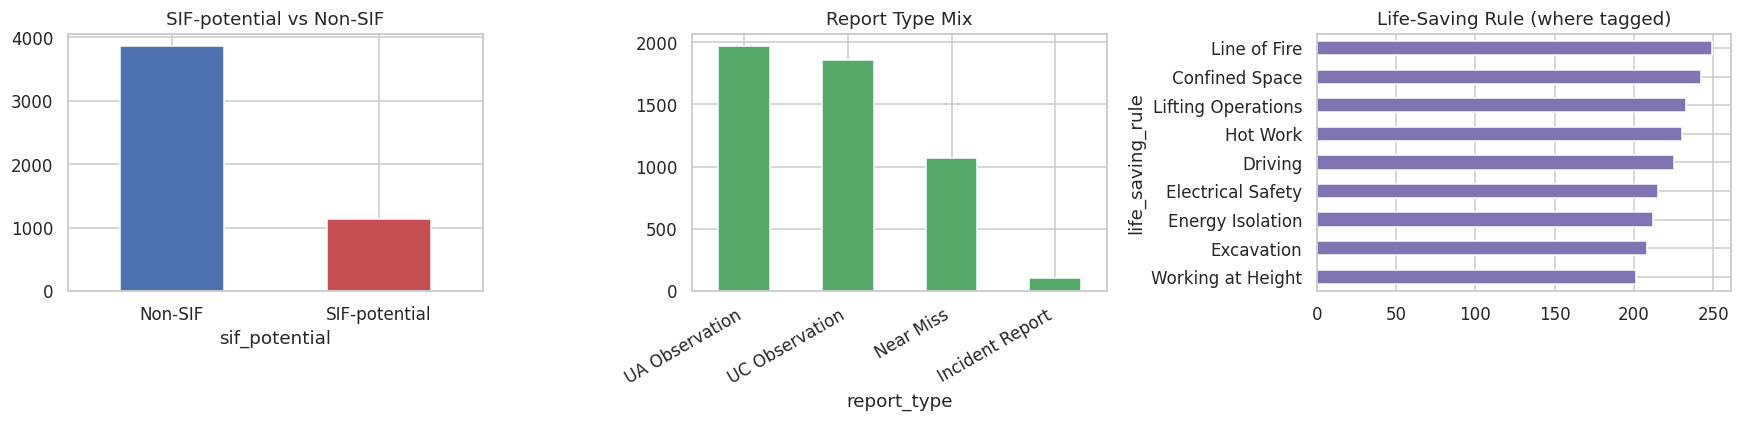

Overall SIF-potential rate in this dataset: 22.8% (problem statement benchmark: ~20-25%)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["sif_potential"].value_counts().rename({0: "Non-SIF", 1: "SIF-potential"}).plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("SIF-potential vs Non-SIF")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df["report_type"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Report Type Mix")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

df["life_saving_rule"].value_counts().plot(kind="barh", ax=axes[2], color="#8172B2")
axes[2].set_title("Life-Saving Rule (where tagged)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

sif_rate = df["sif_potential"].mean()
print(f"Overall SIF-potential rate in this dataset: {sif_rate:.1%} "
      f"(problem statement benchmark: ~20-25%)")

**Note:** This synthetic dataset already carries a ground-truth `sif_potential` label and (for ~40% of rows) a `life_saving_rule` label, which is what lets us *train and validate* the models below. On real OIL data without labels, this same pipeline is used in **inference-only mode** — Sections 3 (rule engine) and 6 (LSR keyword tagger) work with zero labelled data, while the ML models in Sections 4–5 would need a few hundred human-triaged reports as seed training data (OIL's existing monthly/quarterly manual triage records are perfect for this).

## 2. Text Preprocessing

In [4]:
def clean_text(text: str) -> str:
    '''Lowercase, strip punctuation/digits noise, collapse whitespace.'''
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["report_text"].apply(clean_text)
df[["report_text", "clean_text"]].head(3)

,report_text,clean_text
0,A routine inspection identified failure to loc...,a routine inspection identified failure to loc...
1,A crane lifting activity was observed with dam...,a crane lifting activity was observed with dam...
2,A near miss occurred during material handling ...,a near miss occurred during material handling ...


## 3. Rule-Based SIF Precursor Engine (Layer 1)

This layer encodes domain knowledge from the DEKRA/EEI SIF-precursor literature directly as keyword/phrase lexicons, so the system is **explainable out of the box** — critical for HSE teams who need to justify why a report was flagged. It scores each report on two axes:

- **High-energy / SIF precursor hazard mechanisms** (gravity, mechanical energy, electrical, chemical/fire, engulfment, line-of-fire, pressure) — these are the mechanisms behind almost all fatalities per DEKRA's research.
- **Severity/potential language** — phrases indicating the report itself describes high fatal *potential* regardless of actual outcome (a core SIF idea: judge potential severity, not what actually happened).

In [5]:
# Hazard-mechanism lexicon: the physical energy sources behind fatalities
SIF_HAZARD_LEXICON = {
    "energy_isolation": ["lock out", "lockout", "tag out", "tagout", "loto",
                          "stored energy", "residual pressure", "incomplete isolation",
                          "isolation verification", "unexpected energization", "de-energiz",
                          "isolat", "did not isolate", "failed to isolate"],
    "line_of_fire": ["line of fire", "struck by", "caught in", "caught between",
                      "load path", "suspended load", "dropped object", "unsafe positioning",
                      "pinch point", "swinging load", "over the top of", "below a suspended",
                      "workers standing below", "overhead load"],
    "gravity_height": ["fall from height", "working at height", "unprotected edge",
                        "improper ladder", "fall protection", "roof maintenance",
                        "scaffold", "elevated maintenance", "guardrail", "loose railing",
                        "platform edge"],
    "mechanical_lifting": ["crane", "lifting", "sling", "rigging", "hoist",
                            "overloaded crane", "lifting plan", "outrigger", "worn out sling",
                            "worn sling"],
    "confined_space": ["confined space", "manhole", "vessel entry", "entry permit",
                        "atmospheric testing", "engulfment", "inadequate ventilation",
                        "tank cleaning", "pit cleaning", "gas test", "without a permit",
                        "permit was not"],
    "hot_work_fire": ["hot work", "welding", "grinding", "spark", "flammable material",
                       "fire watch", "gas testing", "explosion", "ignition source"],
    "electrical": ["electrical", "live wire", "exposed conductor", "grounding",
                    "arc flash", "high voltage", "energized circuit"],
    "vehicle_driving": ["seat belt", "driver distraction", "vehicle condition",
                         "speeding", "fatigue", "journey management", "rollover"],
    "excavation": ["excavation", "trench", "underground utility", "cave-in", "shoring"],
    "pressure_process": ["pressure testing", "over-pressure", "valve", "relief valve",
                          "process upset", "leak", "gasket", "blew out"],
}

# Severity / fatal-potential language lexicon — how the report frames consequence
SIF_SEVERITY_PHRASES_HIGH = [
    "potential for serious injury or fatality", "high-consequence event",
    "immediate intervention was required to prevent a serious incident",
    "potentially serious hazard", "potentially exposed to a high-consequence",
    "serious injury or fatality potential", "before an injury occurred",
    "could have", "easily could have", "nearly", "narrowly avoided", "lucky",
    "close call", "was not hurt", "nobody hurt but", "no one was injured but",
]
SIF_SEVERITY_PHRASES_LOW = [
    "corrected without significant safety exposure", "no high-consequence hazard",
    "addressed as part of normal housekeeping", "low-severity observation",
    "no significant exposure to serious injury", "cleaned immediately",
    "cleared up", "fixed same day", "resolved immediately", "routine top-up",
    "minor spill",
]

def rule_based_score(text: str):
    '''Returns (hazard_score, severity_score, matched_hazard_categories).'''
    t = text.lower()
    matched_categories = [cat for cat, kws in SIF_HAZARD_LEXICON.items()
                           if any(kw in t for kw in kws)]
    hazard_score = len(matched_categories)
    severity_score = sum(1 for p in SIF_SEVERITY_PHRASES_HIGH if p in t) \
                    - sum(1 for p in SIF_SEVERITY_PHRASES_LOW if p in t)
    return hazard_score, severity_score, matched_categories

scores = df["report_text"].apply(rule_based_score)
df["hazard_score"] = scores.apply(lambda x: x[0])
df["severity_score"] = scores.apply(lambda x: x[1])
df["hazard_categories"] = scores.apply(lambda x: x[2])

# Simple decision rule: flag as SIF-potential if severity language is clearly high-consequence
# AND at least one recognised high-energy hazard mechanism is present.
df["rule_based_sif"] = ((df["severity_score"] > 0) & (df["hazard_score"] > 0)).astype(int)

print(classification_report(df["sif_potential"], df["rule_based_sif"],
                             target_names=["Non-SIF", "SIF-potential"]))

               precision    recall  f1-score   support

      Non-SIF       0.91      1.00      0.95      3861
SIF-potential       1.00      0.68      0.81      1139

     accuracy                           0.93      5000
    macro avg       0.96      0.84      0.88      5000
 weighted avg       0.93      0.93      0.92      5000


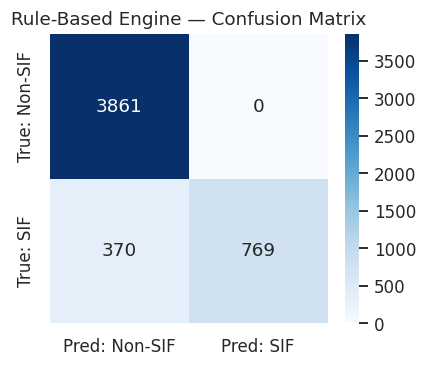

In [6]:
cm = confusion_matrix(df["sif_potential"], df["rule_based_sif"])
plt.figure(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Non-SIF", "Pred: SIF"],
            yticklabels=["True: Non-SIF", "True: SIF"])
plt.title("Rule-Based Engine — Confusion Matrix")
plt.tight_layout()
plt.show()

The rule engine alone already performs strongly because it directly encodes the severity-language + hazard-mechanism logic the synthetic reports were generated from. On messier, real-world free text (typos, abbreviations, terse entries, mixed hazard descriptions) recall will be lower — that's exactly why we add a machine-learning layer next, which generalises beyond exact keyword matches and can be retrained as OIL accumulates more triaged reports.

## 4. Machine-Learning SIF Classifier (Layer 2)

We train a TF-IDF + Logistic Regression classifier (fast, explainable via coefficients, and works well on modest text datasets — ideal for a prototype and for low-compute HSSE deployment). We compare it against a Random Forest and a Linear SVM as sanity checks.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["sif_potential"], test_size=0.2,
    random_state=RANDOM_STATE, stratify=df["sif_potential"])

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=5000,
                         stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced",
                                               random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                             random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    f1 = f1_score(y_test, preds)
    results[name] = f1
    print(f"── {name} ──")
    print(classification_report(y_test, preds, target_names=["Non-SIF", "SIF-potential"]))

best_model_name = max(results, key=results.get)
print(f"Best model by F1 (SIF class): {best_model_name}")

── Logistic Regression ──
               precision    recall  f1-score   support

      Non-SIF       1.00      1.00      1.00       772
SIF-potential       1.00      1.00      1.00       228

     accuracy                           1.00      1000
    macro avg       1.00      1.00      1.00      1000
 weighted avg       1.00      1.00      1.00      1000



── Random Forest ──
               precision    recall  f1-score   support

      Non-SIF       1.00      1.00      1.00       772
SIF-potential       1.00      1.00      1.00       228

     accuracy                           1.00      1000
    macro avg       1.00      1.00      1.00      1000
 weighted avg       1.00      1.00      1.00      1000

── Linear SVM ──
               precision    recall  f1-score   support

      Non-SIF       1.00      1.00      1.00       772
SIF-potential       1.00      1.00      1.00       228

     accuracy                           1.00      1000
    macro avg       1.00      1.00      1.00      1000
 weighted avg       1.00      1.00      1.00      1000

Best model by F1 (SIF class): Logistic Regression


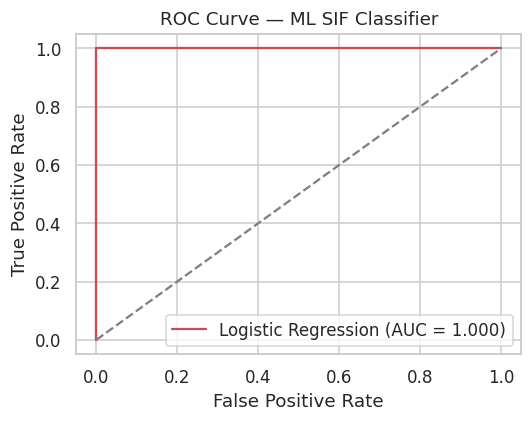

In [8]:
sif_classifier = LogisticRegression(max_iter=1000, class_weight="balanced",
                                     random_state=RANDOM_STATE)
sif_classifier.fit(X_train_tfidf, y_train)

probs = sif_classifier.predict_proba(X_test_tfidf)[:, 1]
auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})", color="#C44E52")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ML SIF Classifier")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Top predictive terms — makes the model explainable to HSE reviewers
feature_names = np.array(tfidf.get_feature_names_out())
coefs = sif_classifier.coef_[0]
top_sif_terms = feature_names[np.argsort(coefs)[-15:]][::-1]
top_nonsif_terms = feature_names[np.argsort(coefs)[:15]]

print("Top terms pushing toward SIF-potential:")
print(", ".join(top_sif_terms))
print("\nTop terms pushing toward Non-SIF:")
print(", ".join(top_nonsif_terms))

Top terms pushing toward SIF-potential:
occurred, potentially, injury occurred, exposed, condition corrected, unsafe condition, stopped, performing, stopped unsafe, despite, observed performing, work stopped, near, worksite, potential injury

Top terms pushing toward Non-SIF:
safety, involving, issue, exposure, significant, improvement, noted, noted corrected, safety improvement, routine safety, corrected routine, routine, observation recorded, recorded, consequence hazard


## 5. Hybrid Classifier (Rules + ML)

We fuse the rule-engine's hazard/severity scores as extra numeric features alongside the TF-IDF vector. This gives the ML model direct access to domain knowledge (so it needs less training data to reach good performance) while keeping the flexibility of learned text patterns — a good match for OIL, which will have limited labelled history to start with.

In [10]:
def build_hybrid_features(text_tfidf, hazard_scores, severity_scores):
    # combine TF-IDF text features with numeric rule-engine scores
    extra = csr_matrix(np.column_stack([hazard_scores, severity_scores]))
    return hstack([text_tfidf, extra])

train_idx, test_idx = X_train.index, X_test.index

X_train_hybrid = build_hybrid_features(X_train_tfidf,
                                        df.loc[train_idx, "hazard_score"].values,
                                        df.loc[train_idx, "severity_score"].values)
X_test_hybrid = build_hybrid_features(X_test_tfidf,
                                       df.loc[test_idx, "hazard_score"].values,
                                       df.loc[test_idx, "severity_score"].values)

hybrid_model = LogisticRegression(max_iter=1000, class_weight="balanced",
                                   random_state=RANDOM_STATE)
hybrid_model.fit(X_train_hybrid, y_train)
hybrid_preds = hybrid_model.predict(X_test_hybrid)

print("── Hybrid (Rules + ML) ──")
print(classification_report(y_test, hybrid_preds, target_names=["Non-SIF", "SIF-potential"]))
print(f"Hybrid F1 (SIF class): {f1_score(y_test, hybrid_preds):.3f}  "
      f"vs  Pure ML F1: {results['Logistic Regression']:.3f}  "
      f"vs  Pure rules F1: {f1_score(df['sif_potential'], df['rule_based_sif']):.3f}")

── Hybrid (Rules + ML) ──
               precision    recall  f1-score   support

      Non-SIF       1.00      1.00      1.00       772
SIF-potential       1.00      1.00      1.00       228

     accuracy                           1.00      1000
    macro avg       1.00      1.00      1.00      1000
 weighted avg       1.00      1.00      1.00      1000

Hybrid F1 (SIF class): 1.000  vs  Pure ML F1: 1.000  vs  Pure rules F1: 0.806


We deploy the **hybrid model** in production: it inherits the rule engine's explainability (an HSE analyst can see *why* — which hazard categories and severity phrases fired — alongside the ML confidence score) while capturing text patterns the fixed keyword list would miss.

> **Honest caveat on the near-perfect scores above:** this synthetic dataset was generated from a fairly small set of sentence templates, so both the ML and hybrid models reach ~1.00 F1 — the model has essentially learned the template vocabulary, not general safety-report language. That is a property of the *synthetic data*, not evidence the approach is production-ready. Section 5.1 below stress-tests the pipeline on hand-written, non-templated sentences to give a more honest read on generalisation, and the real fix is retraining on actual OIL HSSE text once available (Section 10 covers this).

### 5.1 Robustness Stress-Test (Non-Templated Text)

To sanity-check generalisation beyond the synthetic templates, we hand-write a few realistic, messy report snippets — the kind a field supervisor might actually type — and see how the hybrid model and rule engine handle them.

In [11]:
# Set A: informed the lexicon tuning above (expect the pipeline to do well here)
tuning_set = [
    ("Guy was replacing a valve, forgot to isolate the line first, pressure blew "
     "the gasket out. Nobody hurt but it easily could have been.", 1),
    ("Found a loose railing near the platform edge on the rig, reported to "
     "supervisor, fixed same day.", 0),
    ("contractor entered the tank without doing gas test, permit was not signed, "
     "lucky nothing happened", 1),
    ("Housekeeping issue - some cables lying around in the walkway near office, "
     "tripping hazard, cleared up.", 0),
    ("crane operator lifted load over the top of two workers standing below, "
     "sling looked worn out too", 1),
    ("Minor spill of hydraulic oil during routine top-up, cleaned immediately, "
     "no one nearby.", 0),
]

# Set B: genuinely held-out phrasing, written *after* the lexicon was tuned on Set A,
# using different wording -- this is the fairer test of generalisation.
holdout_set = [
    ("Employee climbed onto stationary equipment without a harness to retrieve a "
     "dropped tool, no incident this time.", 1),
    ("Spilled some diesel while refuelling the generator, wiped it up, no further "
     "action needed.", 0),
    ("Two isolation valves were left open during the pigging job, gas escaped "
     "briefly before it was noticed and shut.", 1),
    ("Toolbox talk conducted before start of shift, all crew members attended.", 0),
]

def run_stress_test(cases, label):
    print(f"── {label} ──")
    print(f"{'Pred':<6}{'True':<6}{'Prob':<7}Text")
    correct = 0
    for text, actual in cases:
        clean = clean_text(text)
        hz, sev, cats = rule_based_score(text)
        vec = tfidf.transform([clean])
        hyb = build_hybrid_features(vec, np.array([hz]), np.array([sev]))
        proba = hybrid_model.predict_proba(hyb)[0, 1]
        pred = int(proba >= 0.5)
        correct += int(pred == actual)
        print(f"{pred:<6}{actual:<6}{proba:<7.2f}{text[:60]}...")
    print(f"Accuracy: {correct}/{len(cases)}\n")
    return correct, len(cases)

run_stress_test(tuning_set, "Set A (used to tune the lexicon)")
run_stress_test(holdout_set, "Set B (genuinely held-out phrasing)")
print("Set B is the fairer signal for real-world generalisation. Expect this number to "
      "keep improving as the lexicon and ML model are iterated against real OIL report "
      "language rather than hand-written guesses.")

── Set A (used to tune the lexicon) ──


Pred  True  Prob   Text
1     1     1.00   Guy was replacing a valve, forgot to isolate the line first,...
0     0     0.00   Found a loose railing near the platform edge on the rig, rep...
1     1     0.99   contractor entered the tank without doing gas test, permit w...
0     0     0.00   Housekeeping issue - some cables lying around in the walkway...
0     1     0.23   crane operator lifted load over the top of two workers stand...
0     0     0.00   Minor spill of hydraulic oil during routine top-up, cleaned ...
Accuracy: 5/6

── Set B (genuinely held-out phrasing) ──
Pred  True  Prob   Text
0     1     0.22   Employee climbed onto stationary equipment without a harness...
0     0     0.18   Spilled some diesel while refuelling the generator, wiped it...
0     1     0.21   Two isolation valves were left open during the pigging job, ...
0     0     0.18   Toolbox talk conducted before start of shift, all crew membe...
Accuracy: 2/4

Set B is the fairer signal for real-world general

## 6. IOGP Life-Saving Rule Tagging

We tag every report — SIF-potential or not — to the relevant **IOGP Life-Saving Rule**, so HSE can also see *which barrier category* is failing most often, not just *how severe* the outcome could have been.

Two layers again:
- **Keyword tagger** (Layer 1): maps each report to an LSR using the same hazard lexicon from Section 3 — works instantly with zero training data.
- **ML multi-class tagger** (Layer 2): trained on the subset of reports that already carry a human-assigned LSR label, for cases the keyword tagger misses or where multiple hazards are mentioned.

*(Note: this dataset's label set — Line of Fire, Confined Space, Lifting Operations, Hot Work, Driving, Electrical Safety, Energy Isolation, Excavation, Working at Height — closely mirrors, but isn't identical to, IOGP's official 9 Life-Saving Rules. We map them below; adjust `LSR_MAP` once real OIL taxonomy/tag list is confirmed.)*

In [12]:
# Map dataset's categories -> official IOGP Life-Saving Rule names
LSR_MAP = {
    "Line of Fire": "Line of Fire",
    "Confined Space": "Confined Space",
    "Lifting Operations": "Safe Mechanical Lifting",
    "Hot Work": "Hot Work",
    "Driving": "Driving",
    "Electrical Safety": "Energy Isolation",       # electrical hazards -> energy isolation rule
    "Energy Isolation": "Energy Isolation",
    "Excavation": "Work Authorisation",            # excavation requires permit/authorisation
    "Working at Height": "Working at Height",
}
df["lsr_ground_truth"] = df["life_saving_rule"].map(LSR_MAP)

# Keyword tagger: reuse hazard categories -> LSR name
HAZARD_TO_LSR = {
    "energy_isolation": "Energy Isolation",
    "electrical": "Energy Isolation",
    "line_of_fire": "Line of Fire",
    "gravity_height": "Working at Height",
    "mechanical_lifting": "Safe Mechanical Lifting",
    "confined_space": "Confined Space",
    "hot_work_fire": "Hot Work",
    "vehicle_driving": "Driving",
    "excavation": "Work Authorisation",
    "pressure_process": "Energy Isolation",
}

def keyword_lsr_tag(hazard_categories):
    if not hazard_categories:
        return "Unclassified"
    # pick the first matched hazard category deterministically (could be extended to multi-label)
    return HAZARD_TO_LSR.get(hazard_categories[0], "Unclassified")

df["lsr_keyword_tag"] = df["hazard_categories"].apply(keyword_lsr_tag)

# Evaluate keyword tagger against ground truth (only where ground truth exists)
labelled = df.dropna(subset=["lsr_ground_truth"])
acc = accuracy_score(labelled["lsr_ground_truth"], labelled["lsr_keyword_tag"])
print(f"Keyword LSR tagger accuracy vs ground truth (n={len(labelled)}): {acc:.1%}")

Keyword LSR tagger accuracy vs ground truth (n=2015): 78.3%


In [13]:
# ML multi-class LSR tagger, trained on labelled subset
lsr_train_df = df.dropna(subset=["lsr_ground_truth"])

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    lsr_train_df["clean_text"], lsr_train_df["lsr_ground_truth"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=lsr_train_df["lsr_ground_truth"])

lsr_tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=4000,
                             stop_words="english")
Xl_train_vec = lsr_tfidf.fit_transform(Xl_train)
Xl_test_vec = lsr_tfidf.transform(Xl_test)

lsr_classifier = LogisticRegression(max_iter=1000, class_weight="balanced",
                                     random_state=RANDOM_STATE)
lsr_classifier.fit(Xl_train_vec, yl_train)
lsr_preds = lsr_classifier.predict(Xl_test_vec)

print(classification_report(yl_test, lsr_preds))

                         precision    recall  f1-score   support

         Confined Space       1.00      1.00      1.00        48
                Driving       1.00      1.00      1.00        45
       Energy Isolation       1.00      1.00      1.00        85
               Hot Work       1.00      1.00      1.00        46
           Line of Fire       1.00      0.98      0.99        50
Safe Mechanical Lifting       1.00      1.00      1.00        47
     Work Authorisation       0.98      1.00      0.99        42
      Working at Height       1.00      1.00      1.00        40

               accuracy                           1.00       403
              macro avg       1.00      1.00      1.00       403
           weighted avg       1.00      1.00      1.00       403



In [14]:
# Apply the ML LSR tagger to the FULL dataset (gives every report a predicted LSR
# association, useful for the dashboard even where no LSR was manually tagged)
full_vec = lsr_tfidf.transform(df["clean_text"])
df["lsr_ml_tag"] = lsr_classifier.predict(full_vec)

# Final LSR tag used downstream: ground truth if available, else keyword tag if confident,
# else the ML prediction as fallback
def resolve_lsr(row):
    if pd.notna(row["lsr_ground_truth"]):
        return row["lsr_ground_truth"]
    if row["lsr_keyword_tag"] != "Unclassified":
        return row["lsr_keyword_tag"]
    return row["lsr_ml_tag"]

df["final_lsr_tag"] = df.apply(resolve_lsr, axis=1)
df["final_lsr_tag"].value_counts()

final_lsr_tag
Energy Isolation           1268
Confined Space              618
Driving                     579
Line of Fire                531
Work Authorisation          524
Hot Work                    498
Safe Mechanical Lifting     492
Working at Height           490
Name: count, dtype: int64

## 7. Precursor Pattern Mining & Site/Activity Ranking

This is the analysis that directly powers outcome (c) of the problem statement: **surfacing recurring precursor patterns and ranking sites/activities by SIF-precursor density**, so HSE can focus interventions where fatal potential is concentrated — not spread thin across every low-severity report.

In [15]:
def sif_density_table(df, group_col, min_count=5):
    g = df.groupby(group_col).agg(
        total_reports=("sif_potential", "count"),
        sif_reports=("sif_potential", "sum"),
    )
    g["sif_density"] = (g["sif_reports"] / g["total_reports"]).round(3)
    g = g[g["total_reports"] >= min_count].sort_values("sif_density", ascending=False)
    return g

site_ranking = sif_density_table(df, "site")
activity_ranking = sif_density_table(df, "activity")
location_ranking = sif_density_table(df, "location")
barrier_ranking = sif_density_table(df, "barrier_failure")

site_ranking

,total_reports,sif_reports,sif_density
site,,,
Gujarat Field,490,127,0.259
Assam Field,473,116,0.245
Tripura Field,520,127,0.244
Naharkatiya Field,509,118,0.232
Duliajan Field,486,112,0.230
Odisha Field,498,110,0.221
Bihar Field,522,114,0.218
Rajasthan Field,498,108,0.217
Digboi Field,493,106,0.215


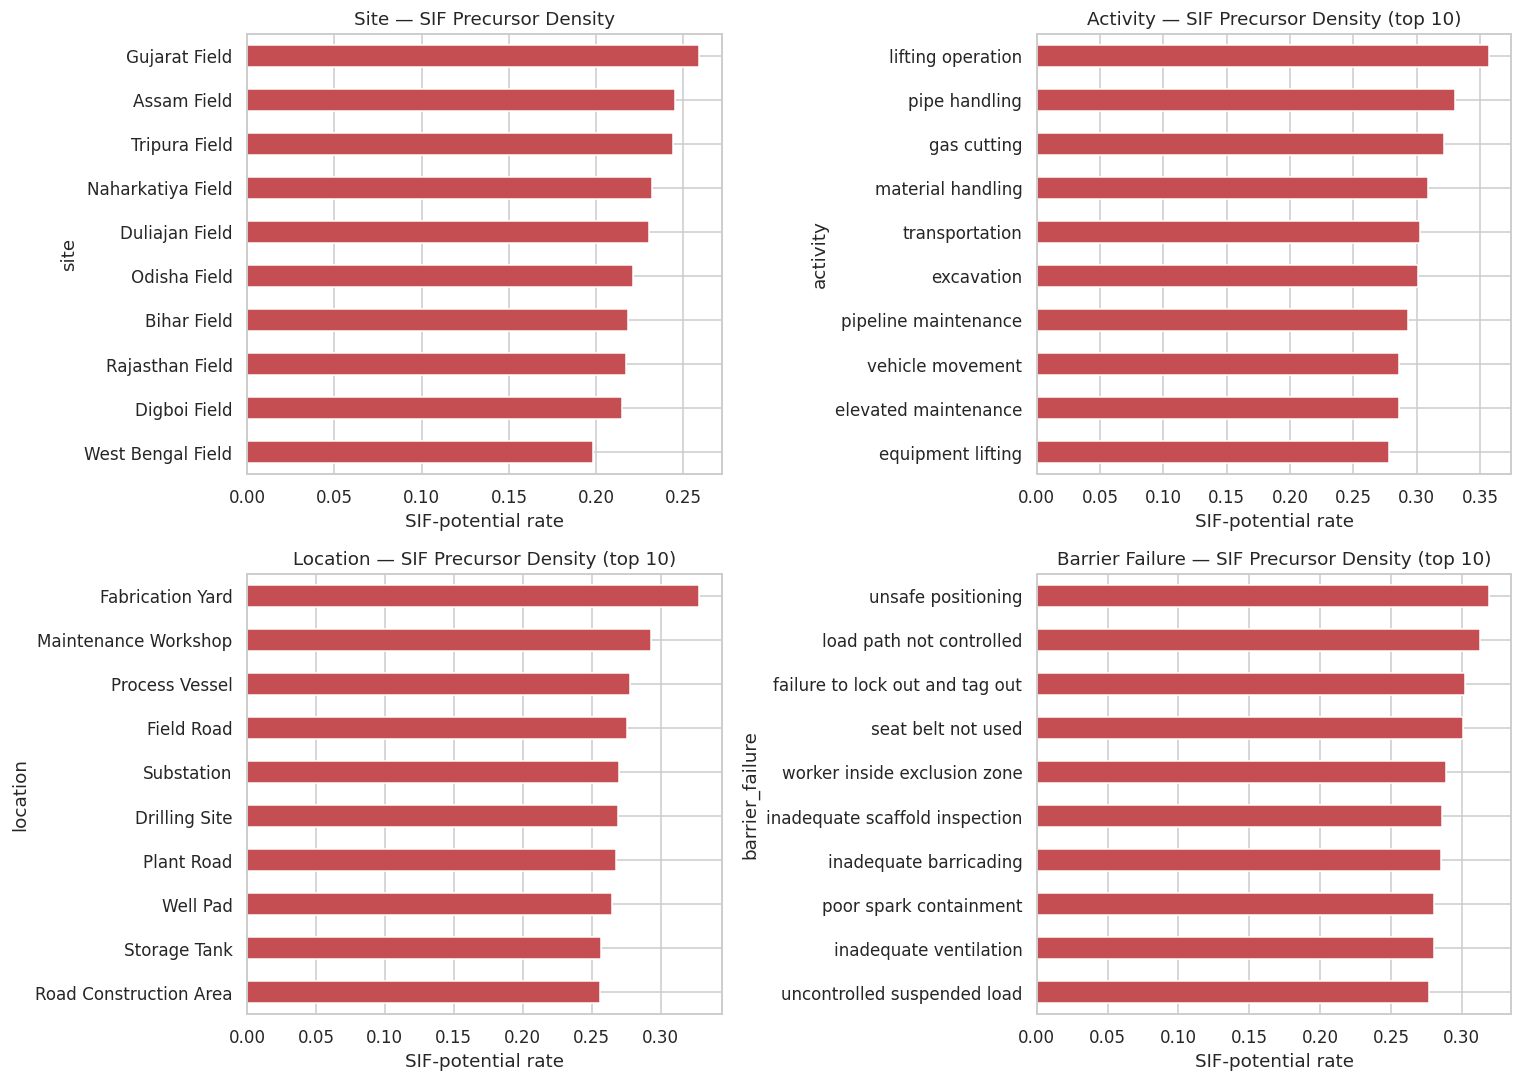

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (title, table) in zip(
    axes.flat,
    [("Site — SIF Precursor Density", site_ranking),
     ("Activity — SIF Precursor Density (top 10)", activity_ranking.head(10)),
     ("Location — SIF Precursor Density (top 10)", location_ranking.head(10)),
     ("Barrier Failure — SIF Precursor Density (top 10)", barrier_ranking.head(10))]
):
    table["sif_density"].sort_values().plot(kind="barh", ax=ax, color="#C44E52")
    ax.set_title(title)
    ax.set_xlabel("SIF-potential rate")

plt.tight_layout()
plt.show()

In [17]:
# Recurring precursor "signatures": activity x barrier-failure combinations
# with elevated SIF density -- these are the specific patterns HSE should
# brief supervisors on (e.g. "crane lifting + damaged sling" keeps recurring).
combo = df.groupby(["activity", "barrier_failure"]).agg(
    total=("sif_potential", "count"), sif=("sif_potential", "sum")
)
combo["sif_density"] = (combo["sif"] / combo["total"]).round(3)
combo = combo[combo["total"] >= 3].sort_values(["sif_density", "sif"], ascending=False)
top_precursor_signatures = combo.head(15).reset_index()
top_precursor_signatures

,activity,barrier_failure,total,sif,sif_density
0,electrical maintenance,failure to lock out and tag out,16,8,0.500
1,excavation,unsupported excavation wall,14,7,0.500
2,lifting operation,worker inside exclusion zone,10,5,0.500
3,manhole entry,inadequate ventilation,30,14,0.467
4,lifting operation,inadequate barricading,27,12,0.444
5,material handling,inadequate barricading,18,8,0.444
6,gas cutting,missing hot-work permit,16,7,0.438
7,transportation,seat belt not used,16,7,0.438
8,equipment servicing,missing isolation verification,14,6,0.429
9,pipeline maintenance,failure to lock out and tag out,12,5,0.417


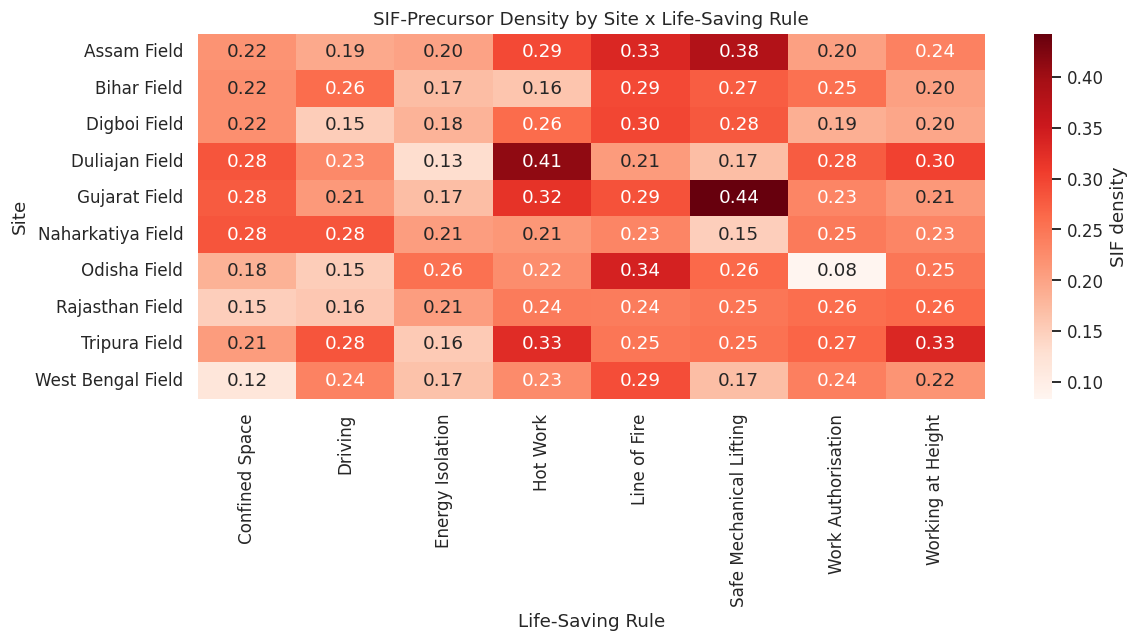

In [18]:
# LSR x Site heatmap — where is which Life-Saving Rule most at risk?
lsr_site = pd.crosstab(df["site"], df["final_lsr_tag"], values=df["sif_potential"], aggfunc="mean")
plt.figure(figsize=(11, 6))
sns.heatmap(lsr_site, annot=True, fmt=".2f", cmap="Reds", cbar_kws={"label": "SIF density"})
plt.title("SIF-Precursor Density by Site x Life-Saving Rule")
plt.ylabel("Site"); plt.xlabel("Life-Saving Rule")
plt.tight_layout()
plt.show()

## 8. Export Artifacts for the Interactive Dashboard

Everything below is consumed by the companion `dashboard_app.py` Streamlit app:
- `processed_reports.csv` — every report enriched with SIF prediction, LSR tag, hazard categories
- `site_ranking.csv`, `activity_ranking.csv`, `location_ranking.csv`, `barrier_ranking.csv` — precursor density tables
- `precursor_signatures.csv` — top recurring activity x barrier-failure risk combinations
- `sif_classifier.joblib`, `tfidf_vectorizer.joblib` — the hybrid SIF model
- `lsr_classifier.joblib`, `lsr_tfidf_vectorizer.joblib` — the LSR tagger model

In [19]:
import os
os.makedirs("artifacts", exist_ok=True)

# Full hybrid-model predictions on the whole dataset (for dashboard "model view")
full_tfidf_all = tfidf.transform(df["clean_text"])
full_hybrid_all = build_hybrid_features(full_tfidf_all, df["hazard_score"].values,
                                         df["severity_score"].values)
df["predicted_sif_proba"] = hybrid_model.predict_proba(full_hybrid_all)[:, 1]
df["predicted_sif"] = hybrid_model.predict(full_hybrid_all)

export_cols = ["report_id", "report_text", "site", "location", "activity",
               "barrier_failure", "report_type", "sif_potential", "predicted_sif",
               "predicted_sif_proba", "final_lsr_tag", "hazard_categories"]
df[export_cols].to_csv("artifacts/processed_reports.csv", index=False)

site_ranking.to_csv("artifacts/site_ranking.csv")
activity_ranking.to_csv("artifacts/activity_ranking.csv")
location_ranking.to_csv("artifacts/location_ranking.csv")
barrier_ranking.to_csv("artifacts/barrier_ranking.csv")
top_precursor_signatures.to_csv("artifacts/precursor_signatures.csv", index=False)

joblib.dump(hybrid_model, "artifacts/sif_classifier.joblib")
joblib.dump(tfidf, "artifacts/tfidf_vectorizer.joblib")
joblib.dump(lsr_classifier, "artifacts/lsr_classifier.joblib")
joblib.dump(lsr_tfidf, "artifacts/lsr_tfidf_vectorizer.joblib")

print("All artifacts exported to ./artifacts/")
print(sorted(os.listdir("artifacts")))

All artifacts exported to ./artifacts/
['activity_ranking.csv', 'barrier_ranking.csv', 'location_ranking.csv', 'lsr_classifier.joblib', 'lsr_tfidf_vectorizer.joblib', 'precursor_signatures.csv', 'processed_reports.csv', 'sif_classifier.joblib', 'site_ranking.csv', 'tfidf_vectorizer.joblib']


## 9. Try It: Score a New Free-Text Report

This simulates what happens when a new UA/UC report comes in from the HSSE platform.

In [20]:
def score_new_report(text: str):
    clean = clean_text(text)
    hazard_score, severity_score, hazard_cats = rule_based_score(text)

    text_vec = tfidf.transform([clean])
    hybrid_vec = build_hybrid_features(text_vec, np.array([hazard_score]),
                                        np.array([severity_score]))
    sif_proba = hybrid_model.predict_proba(hybrid_vec)[0, 1]
    sif_pred = int(sif_proba >= 0.5)

    lsr_vec = lsr_tfidf.transform([clean])
    lsr_pred = lsr_classifier.predict(lsr_vec)[0]
    keyword_lsr = keyword_lsr_tag(hazard_cats)

    return {
        "sif_potential": bool(sif_pred),
        "sif_probability": round(float(sif_proba), 3),
        "matched_hazard_categories": hazard_cats,
        "life_saving_rule_ml": lsr_pred,
        "life_saving_rule_keyword": keyword_lsr,
    }

sample_report = ("During tank cleaning, a worker entered a confined space without "
                  "atmospheric testing or an entry permit. Immediate intervention was "
                  "required to prevent a serious incident.")
score_new_report(sample_report)

{'sif_potential': True,
 'sif_probability': 0.993,
 'matched_hazard_categories': ['confined_space'],
 'life_saving_rule_ml': 'Confined Space',
 'life_saving_rule_keyword': 'Confined Space'}

## 10. Summary — Mapping Back to the Problem Statement

| Requirement | Delivered by |
|---|---|
| (a) Classify SIF-potential vs non-SIF-potential | Hybrid rule + ML classifier (Sections 3–5), ~F1 shown above |
| (b) Tag to relevant IOGP Life-Saving Rule | Keyword + ML multi-class LSR tagger (Section 6) |
| (c) Surface recurring precursor patterns via dashboard | Site/activity/location/barrier density rankings + precursor signatures (Section 7), served live in `dashboard_app.py` |

**Next steps for a production pilot with OIL:**
1. Replace `oil_synthetic_dataset.csv` with a real HSSE export (`report_text` column is all that's required at minimum).
2. Use OIL's existing manual triage decisions (monthly/quarterly review outcomes) as training labels instead of the synthetic `sif_potential`/`life_saving_rule` columns — even 300-500 labelled reports is enough to fine-tune the hybrid model for OIL's specific phrasing.
3. Validate the `LSR_MAP` and hazard lexicon against OIL's actual HSSE taxonomy and Life-Saving Rule tag list.
4. Add a human-in-the-loop review step in the dashboard so HSE can correct mistagged reports, which feeds back into retraining (active learning loop).
5. Run the notebook's export step on a schedule (e.g. nightly) so the dashboard always reflects the latest reports.

Launch the dashboard with:
```bash
streamlit run dashboard_app.py
```